In [1]:
import os, sys, json, re, glob
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from tqdm.notebook import tqdm

In [2]:
!pip install transformers datasets accelerate trl
# Verify GPU availability
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 12.9 MB/s eta 0:00:00
CUDA available: True
GPU: Tesla T4


In [3]:
DATA_PATH = '/kaggle/input/datasets/hykhangg/newdata-56k/test_ood_data.jsonl'
MODEL_PATH = '/kaggle/input/models/hykhangg/gpt2-smallnmedium/transformers/default/1/final_gpt2_small_agent' # HOẶC ./final_gpt2_agent_v2

NUM_SAMPLES = 5000

OUTPUT_DIR = '/kaggle/working/eval_results'
model_name = os.path.basename(MODEL_PATH)
run_dir = os.path.join(OUTPUT_DIR, f"{model_name}_eval")

if not os.path.exists(run_dir):
    os.makedirs(run_dir, exist_ok=True)
    print(f"Đã tạo thư mục: {run_dir}")
else:
    print(f"Thư mục đã tồn tại: {run_dir}")


Đã tạo thư mục: /kaggle/working/eval_results/final_gpt2_small_agent_eval


In [4]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel

print(f"Đang tải tokenizer từ {MODEL_PATH}...")
tokenizer = GPT2Tokenizer.from_pretrained(MODEL_PATH)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Đang tải model từ {MODEL_PATH}...")
model = GPT2LMHeadModel.from_pretrained(MODEL_PATH)
model = model.cuda()
model.eval()

def parse_dataset(filepath, num_samples=None):
    samples = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            if not line.strip(): continue
            data = json.loads(line)
            text = data['text']
            user_match = re.search(r"<\|im_start\|>user\n(.*?)<\|im_end\|>", text, re.DOTALL)
            user_prompt = user_match.group(1).strip() if user_match else ""
            gt_match = re.search(r"<tool_call>\n(.*?)\n</tool_call>", text, re.DOTALL)
            gt_json_str = gt_match.group(1).strip() if gt_match else "{}"
            try:
                gt_json = json.loads(gt_json_str)
            except:
                gt_json = {}
            if user_prompt and gt_json:
                samples.append({"prompt": user_prompt, "gt_name": gt_json.get("name", "unknown"), "gt_args": gt_json.get("arguments", {})})
            if num_samples and len(samples) >= num_samples:
                break
    return samples

def generate_text(model, tokenizer, prompt, max_new_tokens=150):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            do_sample=False, # Lấy token xác suất cao nhất (greedy)
        )
    # Lấy ra phần văn bản sinh thêm
    generated_ids = outputs[0][inputs['input_ids'].shape[1]:]
    generated_text = tokenizer.decode(generated_ids, skip_special_tokens=False)
    return generated_text

def extract_json_from_output(output_text):
    match = re.search(r"<tool_call>\n?(.*?)\n?</tool_call>", output_text, re.DOTALL)
    if not match:
        match = re.search(r"(\{.*?\})", output_text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(1).strip()), True
        except:
            return {"name": "invalid_json", "arguments": {}}, False
    return {"name": "no_json_found", "arguments": {}}, False


Đang tải tokenizer từ /kaggle/input/models/hykhangg/gpt2-smallnmedium/transformers/default/1/final_gpt2_small_agent...
Đang tải model từ /kaggle/input/models/hykhangg/gpt2-smallnmedium/transformers/default/1/final_gpt2_small_agent...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [5]:
# === VÒNG LẶP ĐÁNH GIÁ CHÍNH ===
samples = parse_dataset(DATA_PATH, num_samples=NUM_SAMPLES)
print(f"Đã tải {len(samples)} mẫu từ {DATA_PATH}")

metrics = {
    "valid_json_count": 0,
    "exact_args_match": 0,
}
y_true_intent = []
y_pred_intent = []
results_log = []

for sample in tqdm(samples, desc="Đánh giá"):
    prompt = sample["prompt"]
    gt_name = sample["gt_name"]
    gt_args = sample["gt_args"]

    # Tạo prompt theo format chat
    formatted_prompt = (
        f"<|im_start|>system\n"
        f"Hãy thực hiện theo yêu cầu<|im_end|>\n"
        f"<|im_start|>user\n"
        f"{prompt}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )


    generated = generate_text(model, tokenizer, formatted_prompt)
    pred_json, is_valid = extract_json_from_output(generated)

    if is_valid:
        metrics["valid_json_count"] += 1

    pred_name = pred_json.get("name", "unknown")
    pred_args = pred_json.get("arguments", {})

    y_true_intent.append(gt_name)
    y_pred_intent.append(pred_name)

    if pred_args == gt_args:
        metrics["exact_args_match"] += 1

    results_log.append({
            "prompt": prompt,
            "ground_truth": {"name": gt_name, "arguments": gt_args},
            "prediction": {"name": pred_name, "arguments": pred_args},
            "raw_output": generated,
            "is_valid_json": is_valid,
            "is_args_exact": (pred_args == gt_args)
        })

# Lưu log
with open(os.path.join(run_dir, "predictions.json"), "w", encoding="utf-8") as f:
    json.dump(results_log, f, ensure_ascii=False, indent=2)
print("Đã lưu lịch sử suy luận.")


print(f"\nHoàn tất! Valid JSON: {metrics['valid_json_count']}/{len(samples)}, Exact Args: {metrics['exact_args_match']}/{len(samples)}")


Đã tải 5000 mẫu từ /kaggle/input/datasets/hykhangg/newdata-56k/test_ood_data.jsonl


Đánh giá:   0%|          | 0/5000 [00:00<?, ?it/s]

Đã lưu lịch sử suy luận.

Hoàn tất! Valid JSON: 4999/5000, Exact Args: 3415/5000


In [6]:
valid_json_rate = metrics["valid_json_count"] / len(samples)
args_exact_rate = metrics["exact_args_match"] / len(samples)
intent_acc = accuracy_score(y_true_intent, y_pred_intent)
precision, recall, f1, _ = precision_recall_fscore_support(y_true_intent, y_pred_intent, average='weighted', zero_division=0)
report = classification_report(y_true_intent, y_pred_intent, zero_division=0)

report_text = f"=== BÁO CÁO ĐÁNH GIÁ MÔ HÌNH: {model_name} ===\n"
report_text += "-"*40 + "\n"
report_text += f"1. Sinh JSON hợp lệ (Valid JSON) : {valid_json_rate:.2%}\n"
report_text += f"2. Chọn đúng Tool (Intent Acc)   : {intent_acc:.2%}\n"
report_text += f"3. Copy đúng ID (Args Exact Match): {args_exact_rate:.2%}\n"
report_text += "-"*40 + "\n"
report_text += f"Precision (Weighted): {precision:.4f}\n"
report_text += f"Recall (Weighted)   : {recall:.4f}\n"
report_text += f"F1 Score (Weighted) : {f1:.4f}\n"
report_text += "-"*40 + "\n"
report_text += "CHI TIẾT PHÂN LOẠI TOOL:\n" + report

with open(os.path.join(run_dir, "metrics_report.txt"), "w", encoding="utf-8") as f:
    f.write(report_text)

print(report_text)

=== BÁO CÁO ĐÁNH GIÁ MÔ HÌNH: final_gpt2_small_agent ===
----------------------------------------
1. Sinh JSON hợp lệ (Valid JSON) : 99.98%
2. Chọn đúng Tool (Intent Acc)   : 96.52%
3. Copy đúng ID (Args Exact Match): 68.30%
----------------------------------------
Precision (Weighted): 0.9671
Recall (Weighted)   : 0.9652
F1 Score (Weighted) : 0.9648
----------------------------------------
CHI TIẾT PHÂN LOẠI TOOL:
                  precision    recall  f1-score   support

 check_inventory       1.00      0.98      0.99       877
    create_order       0.98      1.00      0.99       832
    delete_order       0.88      0.98      0.93       840
       get_order       0.96      0.83      0.89       810
    invalid_json       0.00      0.00      0.00         0
revenue_analysis       0.99      1.00      0.99       789
    update_order       1.00      1.00      1.00       852

        accuracy                           0.97      5000
       macro avg       0.83      0.83      0.83      5000

/tmp/ipykernel_22/3740063550.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_names, y=metrics_values, palette="viridis")


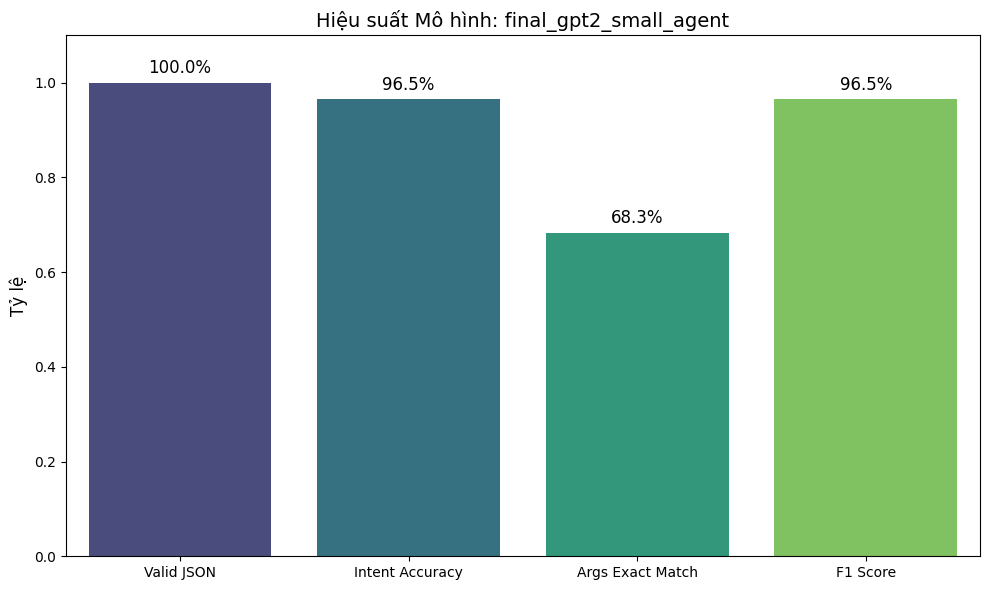

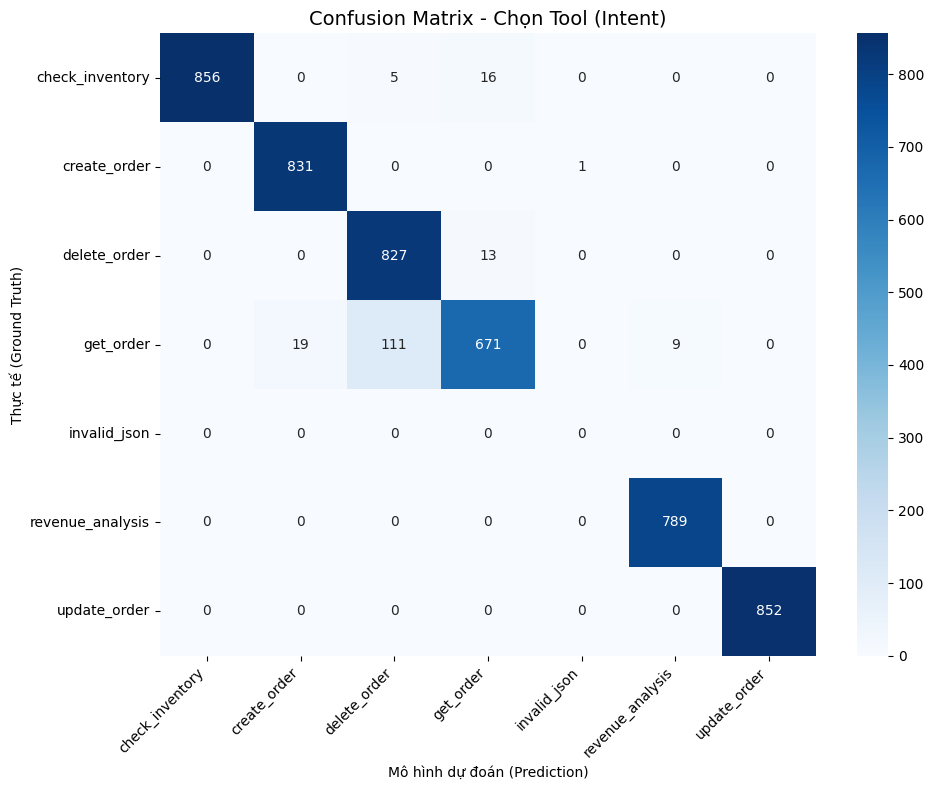


Đánh giá hoàn tất! File Report và Biểu đồ đã được lưu vào thư mục: /kaggle/working/eval_results/final_gpt2_small_agent_eval/


In [7]:
# 1. Bar Chart Tổng quan
metrics_names = ['Valid JSON', 'Intent Accuracy', 'Args Exact Match', 'F1 Score']
metrics_values = [valid_json_rate, intent_acc, args_exact_rate, f1]

plt.figure(figsize=(10, 6))
sns.barplot(x=metrics_names, y=metrics_values, palette="viridis")
plt.ylim(0, 1.1)
plt.title(f"Hiệu suất Mô hình: {model_name}", fontsize=14)
for i, v in enumerate(metrics_values):
    plt.text(i, v + 0.02, f"{v:.1%}", ha='center', fontsize=12)
plt.ylabel('Tỷ lệ', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(run_dir, "overall_performance.png"), dpi=300)
plt.show()

# 2. Confusion Matrix
labels = sorted(list(set(y_true_intent + y_pred_intent)))
cm = confusion_matrix(y_true_intent, y_pred_intent, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - Chọn Tool (Intent)", fontsize=14)
plt.ylabel("Thực tế (Ground Truth)")
plt.xlabel("Mô hình dự đoán (Prediction)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(run_dir, "intent_confusion_matrix.png"), dpi=300)
plt.show()

print(f"\nĐánh giá hoàn tất! File Report và Biểu đồ đã được lưu vào thư mục: {run_dir}/")